# PHẦN 4. ĐÁNH GIÁ MÔ HÌNH & KHOẢNG DỰ ĐOÁN

## 4.1. Phân tích Residual

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Đọc dữ liệu
df = pd.read_csv("../data/msft_macro_2021_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Tính Monthly Return giống 03_mlr.ipynb
df["Monthly_Return"] = df["MSFT_Price"].pct_change() * 100
df = df.dropna(subset=["Monthly_Return"]).reset_index(drop=True)

# Xây dựng lại đúng mô hình OLS
X = df[["Interest_Rate", "Inflation_Rate"]]
Y = df["Monthly_Return"]
X = sm.add_constant(X)

results = sm.OLS(Y, X).fit()

print("Số quan sát:", int(results.nobs))
print("R-squared:", round(results.rsquared, 4))

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-8uc5nfn0 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Số quan sát: 67
R-squared: 0.0113


In [2]:
# Residual và fitted values
fitted_values = results.fittedvalues
residuals = results.resid

residual_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Mean Residual",
        "Std. Dev. Residual",
        "Min Residual",
        "Max Residual"
    ],
    "Giá trị": [
        residuals.mean(),
        residuals.std(ddof=1),
        residuals.min(),
        residuals.max()
    ]
})

display(residual_summary.round(4))

,Chỉ tiêu,Giá trị
0,Mean Residual,-0.0000
1,Std. Dev. Residual,7.5978
2,Min Residual,-19.0352
3,Max Residual,22.6395


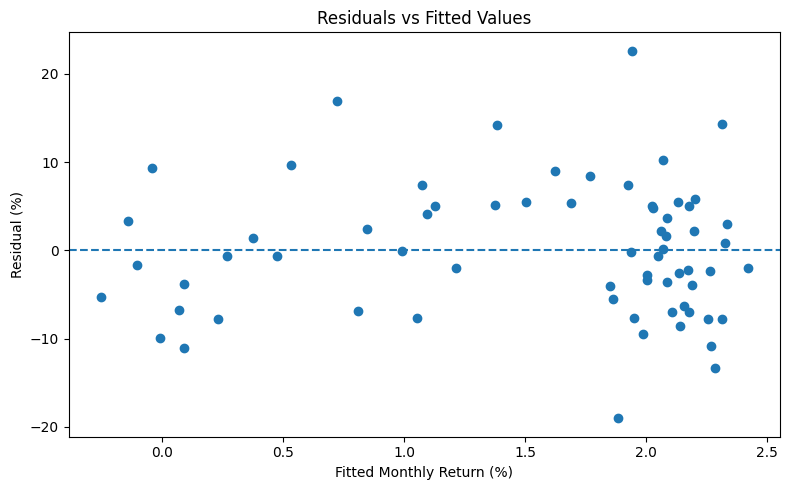

In [3]:
# Residuals vs Fitted Values
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Monthly Return (%)")
plt.ylabel("Residual (%)")
plt.tight_layout()
plt.show()

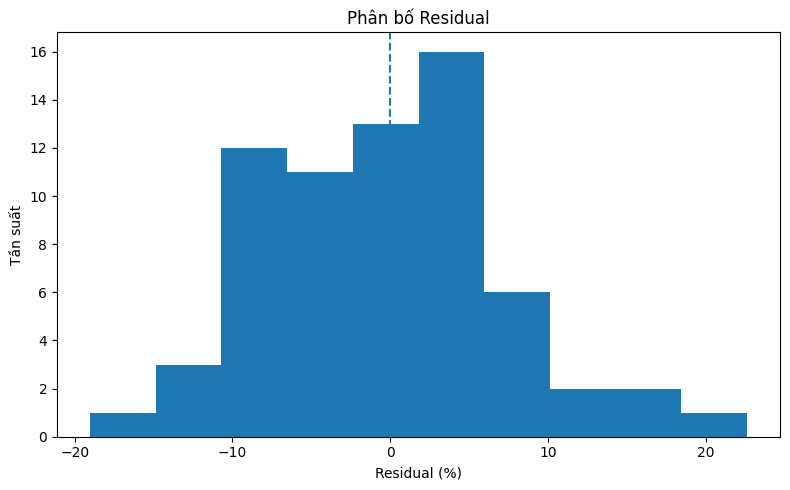

In [4]:
# Phân bố Residual
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=10)
plt.axvline(0, linestyle="--")
plt.title("Phân bố Residual")
plt.xlabel("Residual (%)")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

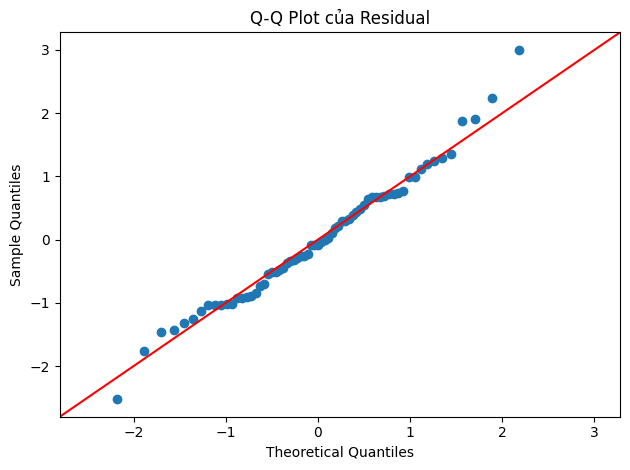

Durbin-Watson: 2.0599


In [5]:
# Q-Q Plot và Durbin-Watson
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot của Residual")
plt.tight_layout()
plt.show()

print(
    "Durbin-Watson:",
    round(sm.stats.stattools.durbin_watson(residuals), 4)
)

## 4.2. Tính và đánh giá RSE

In [6]:
# Residual Standard Error
SSE = np.sum(residuals ** 2)
RSE = np.sqrt(SSE / results.df_resid)

print(f"SSE = {SSE:.4f}")
print(f"RSE = {RSE:.4f} điểm phần trăm")

SSE = 3809.9492
RSE = 7.7156 điểm phần trăm


## 4.3. Confidence Interval (CI)

In [7]:
# Dùng giá trị trung bình của hai biến độc lập
interest_mean = df["Interest_Rate"].mean()
inflation_mean = df["Inflation_Rate"].mean()

x0 = pd.DataFrame({
    "const": [1.0],
    "Interest_Rate": [interest_mean],
    "Inflation_Rate": [inflation_mean]
})[X.columns]

prediction = results.get_prediction(x0)
pred = prediction.summary_frame(alpha=0.05)

ci_table = pd.DataFrame({
    "Interest_Rate (%)": [interest_mean],
    "Inflation_Rate (%)": [inflation_mean],
    "Monthly_Return dự báo (%)": [pred.loc[0, "mean"]],
    "CI 95% - Lower (%)": [pred.loc[0, "mean_ci_lower"]],
    "CI 95% - Upper (%)": [pred.loc[0, "mean_ci_upper"]]
})

display(ci_table.round(4))

,Interest_Rate (%),Inflation_Rate (%),Monthly_Return dự báo (%),CI 95% - Lower (%),CI 95% - Upper (%)
0,3.324,4.3948,1.5273,-0.3558,3.4103


## 4.4. Prediction Interval (PI)

In [8]:
pi_table = pd.DataFrame({
    "Monthly_Return dự báo (%)": [pred.loc[0, "mean"]],
    "PI 95% - Lower (%)": [pred.loc[0, "obs_ci_lower"]],
    "PI 95% - Upper (%)": [pred.loc[0, "obs_ci_upper"]]
})

display(pi_table.round(4))

ci_width = pred.loc[0, "mean_ci_upper"] - pred.loc[0, "mean_ci_lower"]
pi_width = pred.loc[0, "obs_ci_upper"] - pred.loc[0, "obs_ci_lower"]

print(f"Độ rộng CI = {ci_width:.4f} điểm phần trăm")
print(f"Độ rộng PI = {pi_width:.4f} điểm phần trăm")

,Monthly_Return dự báo (%),PI 95% - Lower (%),PI 95% - Upper (%)
0,1.5273,-14.001,17.0555


Độ rộng CI = 3.7662 điểm phần trăm
Độ rộng PI = 31.0566 điểm phần trăm


## 4.5. Phân biệt CI và PI

In [9]:
comparison = pd.DataFrame({
    "Tiêu chí": [
        "Đối tượng ước lượng",
        "Nguồn bất định",
        "Độ rộng"
    ],
    "Confidence Interval (CI)": [
        "Giá trị trung bình kỳ vọng",
        "Sai số ước lượng trung bình",
        "Hẹp hơn"
    ],
    "Prediction Interval (PI)": [
        "Một quan sát mới",
        "Sai số trung bình + biến động quan sát mới",
        "Rộng hơn"
    ]
})

display(comparison)

,Tiêu chí,Confidence Interval (CI),Prediction Interval (PI)
0,Đối tượng ước lượng,Giá trị trung bình kỳ vọng,Một quan sát mới
1,Nguồn bất định,Sai số ước lượng trung bình,Sai số trung bình + biến động quan sát mới
2,Độ rộng,Hẹp hơn,Rộng hơn
